# Issue #26 — Sentiment baseline (VADER)

**Dataset real**:
- `data/raw/csv/review_data.csv`

**Output**:
- `data/processed/reviews_with_sentiment.csv`

Se calcula:
- `sentiment_score` (compound VADER, rango [-1, 1])
- `sentiment_label` (negative/neutral/positive)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

reviews = pd.read_csv("../data/raw/csv/review_data.csv")
sent = pd.read_csv("../data/processed/reviews_with_sentiment.csv")

print(reviews.shape, sent.shape)
sent.head()

(1538, 12) (1538, 14)


,pd_id,AuthorId,Rating,Title,ReviewText,Helpfulness,SubmissionTime,IsRecommended,eyeColor,hairColor,skinTone,skinType,sentiment_score,sentiment_label
0,P513098,34708283257,5,SO good!,"I have always suffered with a dry scalp and, a...",1.0,2026-02-06 15:34:00+00:00,True,NaN,black,NaN,NaN,-0.7367,negative
1,P513098,2175802834,5,NaN,This thing is a miracle in a bottle. It finall...,1.0,2026-02-01 14:09:55+00:00,True,NaN,brown,NaN,NaN,0.7556,positive
2,P513098,9099093786,4,saves me from the post-wash dry flaky scalp,I bought this because my scalp gets very dry a...,1.0,2025-11-01 04:23:00+00:00,True,NaN,black,NaN,NaN,0.9557,positive
3,P513098,2457522697,1,NaN,Didn’t any difference using this product and i...,1.0,2025-08-26 13:50:37+00:00,False,NaN,brown,NaN,NaN,0.6202,positive
4,P513098,12903380383,5,NaN,So far this has helped! My roots look so hydra...,1.0,2025-07-08 12:06:44+00:00,True,brown,black,deep,comboSk,0.5355,positive


## 1) Calidad mínima de datos
- Nulos en ReviewText
- Distribución de ratings

In [2]:
print("Nulos ReviewText:", reviews["ReviewText"].isna().sum())
print("Nulos Rating:", reviews["Rating"].isna().sum())

rating_counts = reviews["Rating"].value_counts().sort_index()
rating_counts

Nulos ReviewText: 1
Nulos Rating: 0


Rating
1      71
2      43
3      63
4     123
5    1238
Name: count, dtype: int64

## 2) Distribución de `sentiment_score` y `sentiment_label`

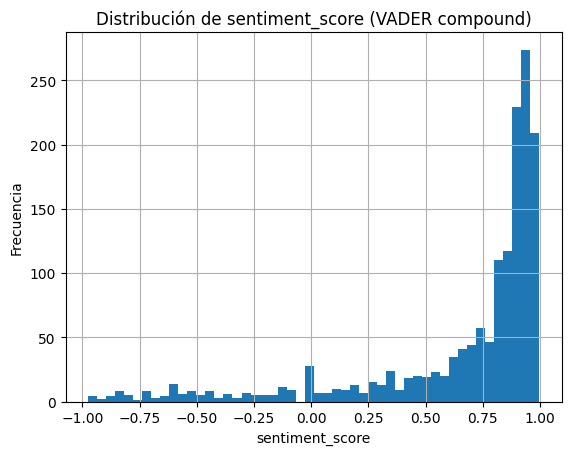

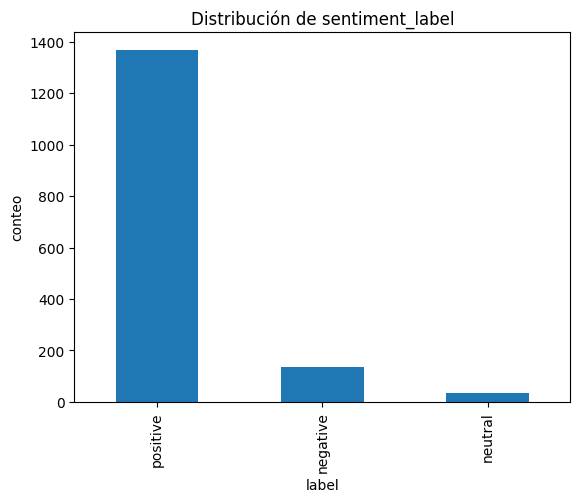

In [3]:
plt.figure()
sent["sentiment_score"].hist(bins=50)
plt.title("Distribución de sentiment_score (VADER compound)")
plt.xlabel("sentiment_score")
plt.ylabel("Frecuencia")
plt.show()

plt.figure()
sent["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Distribución de sentiment_label")
plt.xlabel("label")
plt.ylabel("conteo")
plt.show()

## 3) Relación entre Rating y Sentiment

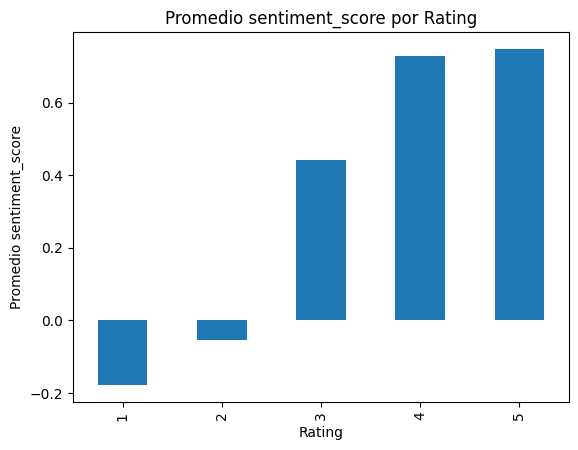

In [4]:
# promedio de sentiment por rating
by_rating = sent.groupby("Rating")["sentiment_score"].mean()
by_rating

plt.figure()
by_rating.plot(kind="bar")
plt.title("Promedio sentiment_score por Rating")
plt.xlabel("Rating")
plt.ylabel("Promedio sentiment_score")
plt.show()

## 4) Ejemplos (top positivos / top negativos)

In [5]:
cols = ["pd_id", "Rating", "sentiment_score", "ReviewText"]
top_pos = sent.sort_values("sentiment_score", ascending=False)[cols].head(5)
top_neg = sent.sort_values("sentiment_score", ascending=True)[cols].head(5)

top_pos

,pd_id,Rating,sentiment_score,ReviewText
226,P513880,5,0.9962,Haircare is very important to me and its impor...
1074,P515486,5,0.9951,"I have sensitive, rosacea-prone skin that gets..."
388,P515494,5,0.9951,"I have sensitive, rosacea-prone skin that gets..."
1036,P515491,5,0.9931,Atobarrier 365 Hydro Cera-HA Serum is a game-c...
44,P513098,5,0.9919,Gifted by Act + Acre. The Daily Hydro™ Scalp S...


In [6]:
top_neg

,pd_id,Rating,sentiment_score,ReviewText
543,P515494,1,-0.9749,It does moustirize... but it broke me out SO b...
1229,P515486,1,-0.9749,It does moustirize... but it broke me out SO b...
610,P515494,1,-0.9610,"I don’t know why it smells like a nail glue, d..."
1296,P515486,1,-0.9610,"I don’t know why it smells like a nail glue, d..."
437,P515494,1,-0.9130,I am so disappointed they ruined a perfect moi...


## Hallazgos preliminares
- (1) La distribución de `sentiment_score` muestra …
- (2) La mayoría de reseñas caen en label …
- (3) En promedio, ratings altos tienden a …
- (4) Los extremos (más positivos/negativos) suelen contener lenguaje …